In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn import datasets
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import kagglehub
from scipy.io import arff
from ucimlrepo import fetch_ucirepo 
from imblearn.under_sampling import RandomUnderSampler

c:\Users\ejeme\Documents\python_repos\selective-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset : https://www.openml.org/search?type=data&sort=version&status=any&order=asc&exact_name=BNG%28SPECTF%29&id=1212

In [4]:
# fetch dataset 
spectf_heart = fetch_ucirepo(id=96) 
  
# data (as pandas dataframes) 
X = spectf_heart.data.features 
Y = spectf_heart.data.targets 
  
# variable information 
print(spectf_heart.variables) 

         name     role     type demographic description units missing_values
0   diagnosis   Target  Integer        None        None  None             no
1         F1R  Feature  Integer        None        None  None             no
2         F1S  Feature  Integer        None        None  None             no
3         F2R  Feature  Integer        None        None  None             no
4         F2S  Feature  Integer        None        None  None             no
5         F3R  Feature  Integer        None        None  None             no
6         F3S  Feature  Integer        None        None  None             no
7         F4R  Feature  Integer        None        None  None             no
8         F4S  Feature  Integer        None        None  None             no
9         F5R  Feature  Integer        None        None  None             no
10        F5S  Feature  Integer        None        None  None             no
11        F6R  Feature  Integer        None        None  None             no

In [5]:
X.shape

(267, 44)

In [6]:
print('Proportion of 1s:', np.round(Y.sum()/len(Y),2))

Proportion of 1s: diagnosis    0.79
dtype: float64


In [10]:
# split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5, random_state=0, stratify=Y)

## <font color='yellow'> logistic regression

In [11]:
model = LogisticRegression(random_state=0, max_iter=1000)
model.fit(X_train, Y_train)

c:\Users\ejeme\Documents\python_repos\selective-classification\.venv\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ejeme\Documents\python_repos\selective-classification\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=0)

In [12]:
# On test set after model selection
test_pred = model.predict(X_test)
print(classification_report(Y_test, test_pred))
print('Test Accuracy:', accuracy_score(Y_test, test_pred))

              precision    recall  f1-score   support

           0       0.40      0.57      0.47        28
           1       0.87      0.77      0.82       106

    accuracy                           0.73       134
   macro avg       0.64      0.67      0.65       134
weighted avg       0.77      0.73      0.75       134

Test Accuracy: 0.7313432835820896


### Retrieving $\kappa_f$ confidence function

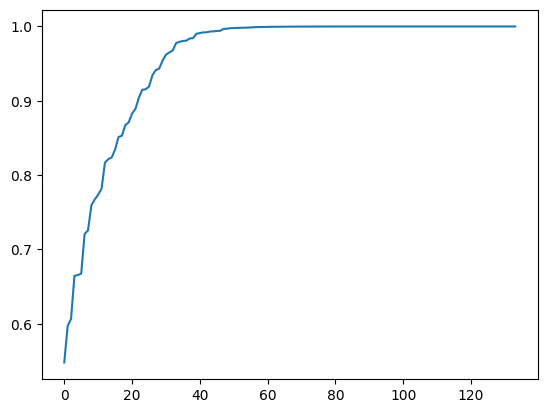

In [23]:
y_true = Y_test.diagnosis
y_pred = test_pred
kappa = model.predict_proba(X_test).max(axis=1)
plt.plot(sorted(kappa))

In [ ]:
sgr_df = pd.DataFrame({'y_true': y_true,
                       'y_pred': y_pred,
                       'kappa': kappa}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
87,1,1,0.547992
126,1,0,0.597125
189,1,1,0.606617
139,1,1,0.664483
214,1,1,0.665586
...,...,...,...
98,1,1,1.000000
228,1,1,1.000000
117,1,1,1.000000
171,1,1,1.000000


In [26]:
pickle.dump(sgr_df, open('sgr_set_log_reg','wb'))

## <font color='yellow'> MLP

In [27]:
# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)

# Define  small MLP 
class SmallMLP(nn.Module):
    def __init__(self, input_dim):
        super(SmallMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Instantiate model, loss, optimizer
input_dim = X_train_tensor.shape[1]
model = SmallMLP(input_dim)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the model
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, Y_train_tensor)
    loss.backward()
    optimizer.step()

    # Optional: Evaluate on test set
    if epoch % 10 == 0 or epoch == epochs - 1:
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test_tensor)
            test_preds_binary = (test_preds > 0.5).float()
            test_acc = (test_preds_binary == Y_test_tensor).float().mean().item()
            print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Test Acc: {test_acc*100:.2f}%")


Epoch 0 | Loss: 0.7321 | Test Acc: 35.07%
Epoch 10 | Loss: 0.5367 | Test Acc: 76.87%
Epoch 20 | Loss: 0.4311 | Test Acc: 79.10%
Epoch 30 | Loss: 0.3512 | Test Acc: 82.84%
Epoch 40 | Loss: 0.2791 | Test Acc: 79.85%
Epoch 50 | Loss: 0.2151 | Test Acc: 78.36%
Epoch 60 | Loss: 0.1702 | Test Acc: 79.85%
Epoch 70 | Loss: 0.1343 | Test Acc: 79.10%
Epoch 80 | Loss: 0.1019 | Test Acc: 80.60%
Epoch 90 | Loss: 0.0768 | Test Acc: 80.60%
Epoch 99 | Loss: 0.0591 | Test Acc: 79.10%


In [28]:
model.eval()
with torch.no_grad():
    test_probs = model(X_test_tensor)  # Shape: (num_samples, 1)
    test_preds = (test_probs > 0.5).float() 

In [30]:
sgr_df = pd.DataFrame({'y_true': Y_test.diagnosis,
                       'y_pred': test_preds.numpy().astype(int).flatten(),
                       'kappa': test_probs.numpy().flatten()}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
260,0,0,0.013873
265,0,0,0.022642
64,0,0,0.028647
60,0,0,0.030991
125,1,0,0.034784
...,...,...,...
98,1,1,1.000000
117,1,1,1.000000
32,1,1,1.000000
216,1,1,1.000000


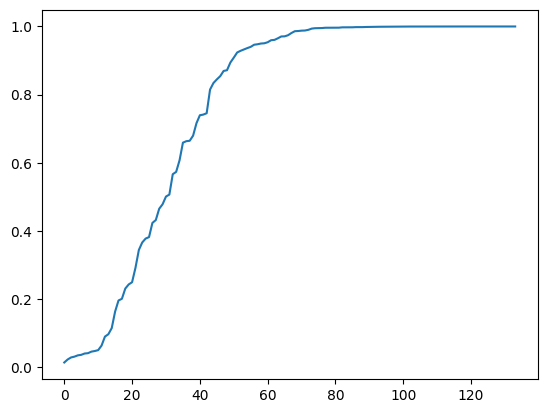

In [31]:
plt.plot(sorted(sgr_df.kappa))
plt.show()

In [32]:
pickle.dump(sgr_df, open('sgr_set_mlp', 'wb'))